In [14]:
# # 🚦 Two-Stage Traffic Sign Recognition — Full GTSRB (43 Classes)
# ## IEEE Ensemble CNN + LLM Semantic Verification

# | Component | Details |
# |-----------|---------|
# | **Primary Classifier** | IEEE Ensemble: ConvNeXt-Tiny + ResNet18 + EfficientNet-B0 (Soft Voting) |
# | **Dataset** | Full GTSRB — 43 classes (0–42) |
# | **LLM Reviewer** | Text-based semantic consistency verification (Configurable API) |
# | **Confidence Gate** | Routes uncertain predictions to LLM for verification |

# ### Architecture:
# 1. **Stage 1:** IEEE Ensemble CNN predicts with confidence + uncertainty metrics
# 2. **Stage 2:** Confidence Gate decides if LLM review is needed
# 3. **Stage 3:** LLM performs semantic consistency verification (text-only, no images)

In [15]:
## 📦 Cell 1: System Check & Imports

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import Counter, defaultdict
from pathlib import Path
from tqdm import tqdm
import time
import json
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
                      else 'cpu')

print("=" * 70)
print("  TWO-STAGE SYSTEM — Full GTSRB (43 Classes)")
print("=" * 70)
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"PyTorch : {torch.__version__}")
print("=" * 70)

  TWO-STAGE SYSTEM — Full GTSRB (43 Classes)
Device  : cuda
GPU     : Tesla T4
PyTorch : 2.9.0+cu128


In [16]:
## 📁 Cell 2: Configuration & Paths

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = '/content/drive/MyDrive/GTSRB_TwoStage'
    MODEL_DIR = Path(DRIVE_BASE)
    # Add Drive folder to sys.path so model_architectures.py & llm_reviewer.py are importable
    if str(MODEL_DIR) not in sys.path:
        sys.path.insert(0, str(MODEL_DIR))
    # Look for test data: first in Drive folder, then /content/model_data
    if (Path(DRIVE_BASE) / 'model_data' / 'test').exists():
        
        DATA_DIR = Path(DRIVE_BASE) / 'model_data'
    elif Path('/content/model_data/test').exists():
        DATA_DIR = Path('/content/model_data')
    else:
        DATA_DIR = Path(DRIVE_BASE) / 'model_data'  # default, will warn later if missing
    print(f"  Environment: Google Colab")
    print(f"  Models from: {MODEL_DIR}")
else:
    # Local: models and data are in same directory structure
    MODEL_DIR = Path('.')  # TotalDataSetLLm folder
    # Find model_data
    _candidates = [Path("model_data"), Path("../model_data"),
                   Path.home() / "Desktop" / "llm" / "model_data"]
    DATA_DIR = next((p for p in _candidates
                     if (p / "train").exists() and (p / "test").exists()), None)
    if DATA_DIR is None:
        print("WARNING: model_data not found! Test images may not be available.")
        print("  Expected at: ../model_data/test/")
    else:
        print(f"  Environment: Local")
        print(f"  Data at: {DATA_DIR.resolve()}")

print(f"  Models at: {MODEL_DIR.resolve()}")

# ── Centralized LLM API Configuration (edit only here to switch provider/model) ──
LLM_API_CONFIG = {
    'provider': 'openrouter',
    'base_url': 'https://openrouter.ai/api/v1',
    'api_key_env': 'OPENROUTER_API_KEY',
    'api_key': os.getenv('OPENROUTER_API_KEY', 'your_openrouter_api_key_here'),
    'primary_model': 'meta-llama/llama-3.1-8b-instruct',
    'fallback_models': ['deepseek/deepseek-chat', 'google/gemma-2-9b-it:free'],
    'temperature': 0.2,
    'max_tokens': 500,
}
print(f"  LLM provider: {LLM_API_CONFIG['provider']}")
print(f"  LLM model: {LLM_API_CONFIG['primary_model']}")

# ── Full GTSRB 43-class names ──
SIGN_NAMES = {
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5t",
    11: "Right-of-way at next intersection", 12: "Priority road",
    13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles over 3.5t prohibited", 17: "No entry",
    18: "General caution", 19: "Dangerous curve to the left",
    20: "Dangerous curve to the right", 21: "Double curve",
    22: "Bumpy road", 23: "Slippery road", 24: "Road narrows on the right",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians",
    28: "Children crossing", 29: "Bicycles crossing",
    30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead", 34: "Turn left ahead", 35: "Ahead only",
    36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left", 40: "Roundabout mandatory",
    41: "End of no passing", 42: "End of no passing for vehicles over 3.5t",
}

NUM_CLASSES = 43
IMG_SIZE = 32
BATCH_SIZE = 128

print(f"  Classes: {NUM_CLASSES}")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Environment: Google Colab
  Models from: /content/drive/MyDrive/GTSRB_TwoStage
  Models at: /content/drive/MyDrive/GTSRB_TwoStage
  LLM provider: openrouter
  LLM model: meta-llama/llama-3.1-8b-instruct
  Classes: 43
  Image size: 32x32


In [17]:
## 🏗️ Cell 3: Model Architectures (IEEE Models) — Embedded

import torch
import torch.nn as nn
import torchvision.models as tv_models


# ── 1. ConvNeXt-Tiny ──
# Best for: complex feature hierarchies, modern architecture
# Modification: stride=1 first conv for 32×32 input instead of stride=4
class ConvNeXtTinyTraffic(nn.Module):
    def __init__(self, num_classes=43, pretrained=False):
        super().__init__()
        self.backbone = tv_models.convnext_tiny(
            weights='IMAGENET1K_V1' if pretrained else None)
        # Replace stride-4 stem with stride-1 for 32×32 input
        self.backbone.features[0][0] = nn.Conv2d(3, 96, 3, stride=1, padding=1)
        in_feat = self.backbone.classifier[2].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Flatten(1), nn.LayerNorm(in_feat),
            nn.Linear(in_feat, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes))

    def forward(self, x):
        return self.backbone(x)


# ── 2. Enhanced ResNet18 ──
# Best for: fast training, solid baseline, proven on traffic signs
# Modification: stride-1 conv1, no maxpool (preserves spatial info at 32×32)
class EnhancedResNet18(nn.Module):
    def __init__(self, num_classes=43, pretrained=False):
        super().__init__()
        resnet = tv_models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        resnet.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()
        self.features = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4)
        in_feat = resnet.fc.in_features
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(in_feat, 512), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(0.25),
            nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


# ── 3. EfficientNet-B0 ──
# Best for: parameter efficiency, compound scaling
# Modification: stride-1 stem conv for 32×32
class EfficientNetB0Traffic(nn.Module):
    def __init__(self, num_classes=43, pretrained=False):
        super().__init__()
        self.backbone = tv_models.efficientnet_b0(
            weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone.features[0][0] = nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feat, 512), nn.SiLU(True), nn.Dropout(0.2),
            nn.Linear(512, num_classes))

    def forward(self, x):
        return self.backbone(x)


# ── Factory ──
MODEL_REGISTRY = {
    'convnext_tiny':   ConvNeXtTinyTraffic,
    'resnet18':        EnhancedResNet18,
    'efficientnet_b0': EfficientNetB0Traffic,
}


def get_model(name, num_classes=43):
    """Create a model by name."""
    if name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {name}. Choose from {list(MODEL_REGISTRY.keys())}")
    return MODEL_REGISTRY[name](num_classes=num_classes)


# Print architecture summary
print("IEEE Model Architectures — Full GTSRB (43 classes)")
print("=" * 60)
for name in ['convnext_tiny', 'resnet18', 'efficientnet_b0']:
    m = get_model(name, NUM_CLASSES)
    total_p = sum(x.numel() for x in m.parameters())
    print(f"  {name:<20} {total_p:>12,} params")
    del m
print("=" * 60)
print("✅ Model architectures embedded directly in notebook")

IEEE Model Architectures — Full GTSRB (43 classes)
  convnext_tiny          28,233,899 params
  resnet18               11,573,867 params
  efficientnet_b0         4,685,479 params
✅ Model architectures embedded directly in notebook


In [18]:
## 🔄 Cell 4: Load IEEE Ensemble Models

MODEL_NAMES = ['convnext_tiny', 'resnet18', 'efficientnet_b0']

# ── Method 1: Load from ensemble_config.pth (bundled weights) ──
ensemble_path = MODEL_DIR / 'ensemble_config.pth'
models = {}
ensemble_weights = {}

if ensemble_path.exists():
    print(f"Loading ensemble bundle from: {ensemble_path}")
    ensemble_config = torch.load(ensemble_path, map_location=device, weights_only=False)

    # Create and load each model
    model1 = ConvNeXtTinyTraffic(num_classes=NUM_CLASSES).to(device)
    model2 = EnhancedResNet18(num_classes=NUM_CLASSES).to(device)
    model3 = EfficientNetB0Traffic(num_classes=NUM_CLASSES).to(device)

    model1.load_state_dict(ensemble_config['convnext_tiny_state_dict'])
    model2.load_state_dict(ensemble_config['resnet18_state_dict'])
    model3.load_state_dict(ensemble_config['efficientnet_b0_state_dict'])

    model1.eval()
    model2.eval()
    model3.eval()

    models = {
        'convnext_tiny': model1,
        'resnet18': model2,
        'efficientnet_b0': model3,
    }

    # Equal weights for soft voting (or use accuracy-based if available)
    ensemble_weights = {name: 1.0 / len(MODEL_NAMES) for name in MODEL_NAMES}

    ens_acc = ensemble_config.get('ensemble_accuracy', 'N/A')
    print(f"  ✅ Loaded ensemble bundle!")
    print(f"  Ensemble accuracy: {ens_acc}%")
    print(f"  Weights: {ensemble_weights}")

else:
    # ── Method 2: Load individual ieee_model_*.pth files ──
    print("Ensemble bundle not found. Loading individual model files...")

    for name in MODEL_NAMES:
        model_path = MODEL_DIR / f'ieee_model_{name}.pth'
        if model_path.exists():
            model = get_model(name, NUM_CLASSES)
            ckpt = torch.load(model_path, map_location=device, weights_only=False)
            model.load_state_dict(ckpt['model_state_dict'])
            model.to(device).eval()
            models[name] = model
            acc = ckpt.get('results', {}).get('accuracy', 'N/A')
            print(f"  ✅ Loaded {name} — Accuracy: {acc}%")
        else:
            print(f"  ❌ Model file not found: {model_path}")

    if len(models) == len(MODEL_NAMES):
        ensemble_weights = {name: 1.0 / len(MODEL_NAMES) for name in MODEL_NAMES}
        print(f"\n✅ All {len(models)} models loaded for ensemble!")
    else:
        print(f"\n⚠️ Only {len(models)}/{len(MODEL_NAMES)} models loaded.")
        ensemble_weights = {name: 1.0 / len(models) for name in models}

print(f"\nModels ready: {list(models.keys())}")
print(f"Ensemble weights: {ensemble_weights}")

Loading ensemble bundle from: /content/drive/MyDrive/GTSRB_TwoStage/ensemble_config.pth
  ✅ Loaded ensemble bundle!
  Ensemble accuracy: 99.36658749010293%
  Weights: {'convnext_tiny': 0.3333333333333333, 'resnet18': 0.3333333333333333, 'efficientnet_b0': 0.3333333333333333}

Models ready: ['convnext_tiny', 'resnet18', 'efficientnet_b0']
Ensemble weights: {'convnext_tiny': 0.3333333333333333, 'resnet18': 0.3333333333333333, 'efficientnet_b0': 0.3333333333333333}


In [19]:
## 🤖 Cell 5: LLM Reviewer — Embedded (with Auto-Fallback + IMPROVED LOGIC)

import json
import os
from typing import Dict
import openai
import time


# ═══════════════════════════════════════════════════════════════════
# Full GTSRB 43-class descriptions (for LLM semantic reasoning)
# ═══════════════════════════════════════════════════════════════════
LLM_SIGN_NAMES = {
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5t",
    11: "Right-of-way at next intersection", 12: "Priority road",
    13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles over 3.5t prohibited", 17: "No entry",
    18: "General caution", 19: "Dangerous curve to the left",
    20: "Dangerous curve to the right", 21: "Double curve",
    22: "Bumpy road", 23: "Slippery road", 24: "Road narrows on the right",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians",
    28: "Children crossing", 29: "Bicycles crossing",
    30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead", 34: "Turn left ahead", 35: "Ahead only",
    36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left", 40: "Roundabout mandatory",
    41: "End of no passing", 42: "End of no passing for vehicles over 3.5t",
}

# Semantic groups for GTSRB visual hierarchy reasoning
SEMANTIC_GROUPS = {
    "Speed Limits": [0, 1, 2, 3, 4, 5, 6, 7, 8, 32],
    "Prohibitory": [9, 10, 15, 16, 17, 41, 42],
    "Priority/Stop/Yield": [11, 12, 13, 14],
    "Warning/Danger": [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
    "Mandatory": [33, 34, 35, 36, 37, 38, 39, 40],
}


def get_semantic_group(class_id: int) -> str:
    """Get the semantic group for a GTSRB class ID."""
    for group_name, class_ids in SEMANTIC_GROUPS.items():
        if class_id in class_ids:
            return group_name
    return "Unknown"


class LLMReviewer:
    """
    LLM-based output reviewer for traffic sign classification (43 classes).
    - Text-only input (NO images)
    - Structured JSON output
    - Uses OpenAI-compatible client (provider configured in LLM_API_CONFIG)
    - Automatic fallback to multiple models if rate-limited
    """

    def __init__(self, api_key: str = None, model: str = None, 
                 fallback_models: list = None, base_url: str = None,
                 temperature: float = None, max_tokens: int = None):
        """
        Initialize LLM Reviewer using OpenAI-compatible client.

        Args:
            api_key: API key (or from configured env var)
            model: Primary model name
            fallback_models: List of alternative models to try if primary fails
        """
        cfg = globals().get('LLM_API_CONFIG', {})
        self.api_key = api_key or cfg.get('api_key') or os.getenv(cfg.get('api_key_env', 'OPENROUTER_API_KEY'))
        if not self.api_key:
            raise ValueError(
                f"API key required. Set {cfg.get('api_key_env', 'OPENROUTER_API_KEY')} env var or pass api_key."
            )
        self.model = model or cfg.get('primary_model', 'meta-llama/llama-3.1-8b-instruct')
        self.fallback_models = fallback_models or cfg.get('fallback_models', [])
        self.temperature = temperature if temperature is not None else cfg.get('temperature', 0.2)
        self.max_tokens = max_tokens if max_tokens is not None else cfg.get('max_tokens', 500)
        
        # Create OpenAI client configured by centralized API config
        self.client = openai.OpenAI(
            base_url=base_url or cfg.get('base_url', 'https://openrouter.ai/api/v1'),
            api_key=self.api_key
        )

    def create_prompt(self, cnn_output: Dict) -> str:
        """
        Create structured text prompt for LLM semantic verification.
        NO IMAGE — Text only.
        """
        preds = cnn_output['predictions']
        top1_conf = preds[0]['confidence']
        top2_conf = preds[1]['confidence']
        top3_conf = preds[2]['confidence']
        margin = cnn_output['margin']
        entropy = cnn_output['entropy']

        prompt = f"""You are an independent verification agent for traffic sign recognition.
You must reason about semantic consistency using traffic sign visual hierarchy.

Context:
Traffic sign recognition using an IEEE Ensemble CNN (ConvNeXt-Tiny + ResNet18 + EfficientNet-B0)
with soft-voting on the full GTSRB dataset (43 classes).

GTSRB Traffic Sign Semantic Groups (43 classes):

1. SPEED LIMIT SIGNS (Circular, Red Border, White Background):
   Classes 0-8: 20/30/50/60/70/80/100/120 km/h speed limits
   Class 6: End of speed limit 80 km/h (crossed out)
   Class 32: End of all speed and passing limits

2. PROHIBITORY SIGNS (Circular, Red Border):
   Class 9: No passing
   Class 10: No passing for vehicles over 3.5t
   Class 15: No vehicles
   Class 16: Vehicles over 3.5t prohibited
   Class 17: No entry
   Class 41: End of no passing
   Class 42: End of no passing for vehicles over 3.5t

3. PRIORITY/STOP/YIELD (Distinctive Shapes):
   Class 11: Right-of-way (triangular, white with red border)
   Class 12: Priority road (diamond, yellow)
   Class 13: Yield (inverted triangle)
   Class 14: Stop (octagonal, red)

4. WARNING/DANGER SIGNS (Triangular, Red Border):
   Classes 18-31: General caution, curves, bumpy road, slippery road,
   road narrows, road work, traffic signals, pedestrians,
   children crossing, bicycles, ice/snow, wild animals

5. MANDATORY SIGNS (Circular, Blue Background):
   Classes 33-40: Turn right/left, ahead only, go straight or right/left,
   keep right/left, roundabout

Model Output:
Top-1: {preds[0]['class_name']} (confidence = {top1_conf:.1%})
Top-2: {preds[1]['class_name']} (confidence = {top2_conf:.1%})
Top-3: {preds[2]['class_name']} (confidence = {top3_conf:.1%})

Metrics:
Entropy: {entropy:.3f}
Margin (Top-1 minus Top-2): {margin:.1%}

**CRITICAL REASONING RULES:**

1. **IGNORE NEGLIGIBLE ALTERNATIVES** (Most Important!)
   - If Top-2 confidence < 5%, it's noise — DO NOT consider it meaningful
   - If margin > 50%, Top-1 is dominant — alternatives are irrelevant
   - Example: Top-1 at 79%, Top-2 at 0.7% → Top-2 is meaningless noise, AGREE with Top-1

2. **HIGH CONFIDENCE + LARGE MARGIN** = Strong Prediction
   - If confidence > 70% AND margin > 40% → AGREE (prediction is solid)
   - Cross-group alternatives at <2% are NOT concerning

3. **MODERATE CONFIDENCE + REASONABLE MARGIN** = Acceptable
   - If confidence > 60% AND margin > 25% → AGREE (clear winner)
   - Focus on margin, not absolute thresholds

4. **FINE-GRAINED CONFUSION** = Expected
   - Speed limit signs (20/30/50/60/70/80/100/120) often confused → AGREE
   - Warning signs (triangular) confused among themselves → AGREE
   - Same-group confusion is semantically plausible

5. **STRUCTURAL CONFLICT** = Only if alternatives are MEANINGFUL
   - Different groups (circular vs triangular) with Top-2 > 15% → DISAGREE
   - But if Top-2 < 5%, ignore it even if different group

6. **OUT-OF-DISTRIBUTION** = Near-equal probabilities
   - Top-1 < 50% AND margin < 20% AND different groups → DISAGREE
   - Model is truly confused, not just noisy alternatives

7. **OVERCONFIDENCE** = Suspicious certainty
   - Confidence > 95% BUT Top-2 from different group > 10% → DISAGREE
   - If Top-2 < 5%, this is NOT overconfidence, just noise

Decision Guidelines:
- **AGREE** → confidence + margin indicate reliable prediction (even if alternatives are cross-group at low %)
- **DISAGREE** → genuine confusion between meaningful alternatives from different groups
- **UNCERTAIN** → insufficient evidence or ambiguous pattern

Output STRICT JSON only:
{{
  "decision": "AGREE | DISAGREE | UNCERTAIN",
  "confusion_type": "DOMINANT_PREDICTION | FINE_GRAINED | STRUCTURAL_CONFLICT | OUT_OF_DISTRIBUTION | OVERCONFIDENCE | AMBIGUOUS",
  "reason": "Explain using semantic groups and reasoning rules above",
  "risk_level": "LOW | MEDIUM | HIGH | CRITICAL"
}}"""

        return prompt

    def call_api(self, prompt: str) -> Dict:
        """Call configured OpenAI-compatible API with automatic fallback models."""
        models_to_try = [self.model] + self.fallback_models
        last_error = None
        
        for i, model in enumerate(models_to_try):
            try:
                if i > 0:
                    print(f"   ⚠️ Trying fallback model {i}: {model}")
                
                response = self.client.chat.completions.create(
                    model=model,
                    messages=[
                        {
                            "role": "system",
                            "content": (
                                "You are a traffic sign recognition verifier. "
                                "Analyze CNN predictions for logical consistency. "
                                "Output ONLY valid JSON."
                            ),
                        },
                        {"role": "user", "content": prompt},
                    ],
                    temperature=self.temperature,
                    max_tokens=self.max_tokens,
                )

                llm_output = response.choices[0].message.content

                # Parse JSON from LLM response
                if "```json" in llm_output:
                    llm_output = llm_output.split("```json")[1].split("```")[0].strip()
                elif "```" in llm_output:
                    llm_output = llm_output.split("```")[1].split("```")[0].strip()

                parsed_response = json.loads(llm_output)

                # Validate required fields
                required_fields = ["decision", "reason", "risk_level"]
                if not all(field in parsed_response for field in required_fields):
                    raise ValueError("LLM response missing required fields")

                if parsed_response["decision"] not in ["AGREE", "DISAGREE", "UNCERTAIN"]:
                    raise ValueError(f"Invalid decision: {parsed_response['decision']}")

                if parsed_response["risk_level"] not in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
                    raise ValueError(f"Invalid risk_level: {parsed_response['risk_level']}")

                # Success! Add which model was used
                if i > 0:
                    print(f"   ✅ Success with fallback model: {model}")
                    parsed_response['model_used'] = model
                
                return parsed_response

            except Exception as e:
                last_error = e
                error_str = str(e)
                
                # Check if it's a rate limit error
                if "429" in error_str or "rate limit" in error_str.lower():
                    if i < len(models_to_try) - 1:
                        print(f"   ⚠️ Rate limited on {model}, trying fallback...")
                        time.sleep(0.5)  # Brief pause before retry
                        continue
                    else:
                        print(f"   ❌ All models rate-limited")
                else:
                    # Non-rate-limit error, try next model
                    if i < len(models_to_try) - 1:
                        print(f"   ⚠️ Error with {model}: {error_str[:100]}")
                        continue
        
        # All models failed
        print(f"API Error: {last_error}")
        return {
            "decision": "UNCERTAIN",
            "confusion_type": "AMBIGUOUS",
            "reason": f"API call failed after trying {len(models_to_try)} models: {str(last_error)[:200]}",
            "risk_level": "MEDIUM",
        }

    def review(self, cnn_output: Dict) -> tuple:
        """
        Review CNN output.

        Args:
            cnn_output: Dictionary containing predictions and uncertainty metrics

        Returns:
            (llm_response, prompt): LLM decision and the prompt used
        """
        prompt = self.create_prompt(cnn_output)
        llm_response = self.call_api(prompt)
        return llm_response, prompt


def llm_reviewer_mock(cnn_output: Dict) -> Dict:
    """
    Mock LLM reviewer simulating SEMANTIC reasoning with 43-class visual hierarchy.
    UPDATED: More intelligent handling of negligible alternatives.
    """
    preds = cnn_output['predictions']
    confidence = preds[0]['confidence']
    margin = cnn_output['margin']
    entropy = cnn_output['entropy']

    top1_class = preds[0].get('class_id', -1)
    top2_class = preds[1].get('class_id', -1)
    top2_confidence = preds[1]['confidence']

    # Convert to int if string
    if isinstance(top1_class, str):
        top1_class = int(top1_class)
    if isinstance(top2_class, str):
        top2_class = int(top2_class)

    top1_group = get_semantic_group(top1_class)
    top2_group = get_semantic_group(top2_class)

    # ═══════════════════════════════════════════════════════════════
    # PRIORITY RULE: Ignore negligible alternatives
    # ═══════════════════════════════════════════════════════════════
    
    # Pattern 1: DOMINANT PREDICTION (Large margin = Top-2 is noise)
    if margin > 0.5:
        return {
            "decision": "AGREE",
            "confusion_type": "DOMINANT_PREDICTION",
            "reason": (
                f"Top-1 has {confidence:.1%} confidence with {margin:.1%} margin. "
                f"This is a dominant prediction. Top-2 at {top2_confidence:.1%} is "
                f"negligible noise and should be ignored regardless of semantic group."
            ),
            "risk_level": "LOW",
        }

    # Pattern 2: HIGH CONFIDENCE + GOOD MARGIN
    if confidence > 0.70 and margin > 0.40:
        return {
            "decision": "AGREE",
            "confusion_type": "DOMINANT_PREDICTION",
            "reason": (
                f"High confidence ({confidence:.1%}) with large margin ({margin:.1%}). "
                f"Top-2 alternative at {top2_confidence:.1%} is not meaningful enough "
                f"to warrant concern, even if from different semantic group."
            ),
            "risk_level": "LOW",
        }

    # Pattern 3: MODERATE CONFIDENCE + REASONABLE MARGIN
    if confidence > 0.60 and margin > 0.25:
        return {
            "decision": "AGREE",
            "confusion_type": "CLEAR_WINNER",
            "reason": (
                f"Moderate confidence ({confidence:.1%}) with meaningful margin "
                f"({margin:.1%}). CNN is discriminating well. Alternatives at "
                f"low probability do not warrant concern."
            ),
            "risk_level": "LOW",
        }

    # ═══════════════════════════════════════════════════════════════
    # NOW CHECK SEMANTIC PATTERNS (only if alternatives are meaningful)
    # ═══════════════════════════════════════════════════════════════

    # Pattern 4: FINE-GRAINED CONFUSION (Same semantic group)
    if top1_group == top2_group and top1_group != "Unknown":
        if top1_group == "Speed Limits":
            return {
                "decision": "AGREE",
                "confusion_type": "FINE_GRAINED",
                "reason": (
                    f"Both predictions are speed limit signs (same circular shape, "
                    f"red border). Confusion between numeric values ({confidence:.1%} "
                    f"vs {top2_confidence:.1%}) is expected and plausible."
                ),
                "risk_level": "LOW" if confidence > 0.50 else "MEDIUM",
            }
        return {
            "decision": "AGREE",
            "confusion_type": "FINE_GRAINED",
            "reason": (
                f"Top predictions belong to {top1_group} category (same visual "
                f"structure). Within-group confusion ({confidence:.1%} vs "
                f"{top2_confidence:.1%}) is semantically reasonable."
            ),
            "risk_level": "LOW" if confidence > 0.50 else "MEDIUM",
        }

    # Pattern 5: STRUCTURAL CONFLICT (only if Top-2 is meaningful > 15%)
    if (
        top1_group != top2_group
        and top1_group != "Unknown"
        and top2_group != "Unknown"
        and top2_confidence > 0.15
        and margin < 0.40
    ):
        return {
            "decision": "DISAGREE",
            "confusion_type": "STRUCTURAL_CONFLICT",
            "reason": (
                f"Top-1 ({top1_group}) vs Top-2 ({top2_group}) are from different "
                f"shape categories, and Top-2 at {top2_confidence:.1%} is too high "
                f"to ignore. Margin of {margin:.1%} suggests genuine confusion "
                f"between incompatible shapes."
            ),
            "risk_level": "HIGH",
        }

    # Pattern 6: OUT-OF-DISTRIBUTION (Near-equal + unrelated)
    if (
        confidence < 0.50
        and margin < 0.20
        and top1_group != top2_group
        and top1_group != "Unknown"
        and top2_group != "Unknown"
    ):
        return {
            "decision": "DISAGREE",
            "confusion_type": "OUT_OF_DISTRIBUTION",
            "reason": (
                f"Near-equal probabilities ({confidence:.1%} vs "
                f"{top2_confidence:.1%}) between unrelated categories "
                f"({top1_group} vs {top2_group}). Model appears genuinely "
                f"confused — possible out-of-distribution input."
            ),
            "risk_level": "CRITICAL",
        }

    # Pattern 7: OVERCONFIDENCE (only if Top-2 is meaningful > 10%)
    if (
        confidence > 0.95
        and top1_group != top2_group
        and top2_group != "Unknown"
        and top2_confidence > 0.10
    ):
        return {
            "decision": "DISAGREE",
            "confusion_type": "OVERCONFIDENCE",
            "reason": (
                f"Very high confidence ({confidence:.1%}) but Top-2 is from a "
                f"different category ({top2_group}) at {top2_confidence:.1%}. "
                f"If model were truly certain, alternatives should be from same "
                f"group or negligible. Possible false confidence."
            ),
            "risk_level": "HIGH",
        }

    # Pattern 8: High entropy + same group = reasonable uncertainty
    if entropy > 0.5 and top1_group == top2_group:
        return {
            "decision": "AGREE",
            "confusion_type": "SEMANTIC_VALIDATED",
            "reason": (
                f"High entropy ({entropy:.2f}) appropriately reflects genuine "
                f"ambiguity within {top1_group} category. Model correctly "
                f"expresses uncertainty."
            ),
            "risk_level": "MEDIUM",
        }

    # Default: Truly ambiguous
    return {
        "decision": "UNCERTAIN",
        "confusion_type": "AMBIGUOUS",
        "reason": (
            f"Confidence {confidence:.1%}, margin {margin:.1%}, entropy {entropy:.2f}. "
            f"Pattern doesn't clearly match expected behaviors. "
            f"({top1_group} vs {top2_group})"
        ),
        "risk_level": "MEDIUM",
    }


# ══════════════════════════════════════════════════════════════════
# Initialize LLM Reviewer from centralized API config
# ══════════════════════════════════════════════════════════════════

API_KEY = LLM_API_CONFIG.get('api_key')
PRIMARY_MODEL = LLM_API_CONFIG.get('primary_model')
FALLBACK_MODELS = LLM_API_CONFIG.get('fallback_models', [])
API_BASE_URL = LLM_API_CONFIG.get('base_url')
API_ENV_NAME = LLM_API_CONFIG.get('api_key_env', 'OPENROUTER_API_KEY')

# Create LLM reviewer instance
llm_reviewer = None
USE_REAL_LLM = False

if API_KEY and API_KEY != "your_api_key_here":
    try:
        llm_reviewer = LLMReviewer(
            api_key=API_KEY,
            model=PRIMARY_MODEL,
            fallback_models=FALLBACK_MODELS,
            base_url=API_BASE_URL,
        )
        USE_REAL_LLM = True
        print(f"✅ LLM Reviewer ready (IMPROVED LOGIC)")
        print(f"   Provider: {LLM_API_CONFIG.get('provider', 'custom')}")
        print(f"   Primary: {PRIMARY_MODEL}")
        print(f"   Fallbacks: {len(FALLBACK_MODELS)} models")
        print(f"   Strategy: Ignores negligible alternatives (<5%)")
    except Exception as e:
        print(f"⚠️ Could not initialize LLM: {e}")
        print(f"   Falling back to mock LLM reviewer")
else:
    print("⚠️ API key not set — using mock LLM reviewer")
    print(f"   Set env var {API_ENV_NAME} or set LLM_API_CONFIG['api_key']")
    print(f"   Fallbacks: {len(FALLBACK_MODELS)} models")
    print(f"   Strategy: Ignores negligible alternatives (<5%)")


✅ LLM Reviewer ready (IMPROVED LOGIC)
   Provider: openrouter
   Primary: meta-llama/llama-3.1-8b-instruct
   Fallbacks: 2 models
   Strategy: Ignores negligible alternatives (<5%)


In [20]:
## 🎯 Cell 6: Stage 1 — IEEE Ensemble CNN Prediction

# ── Preprocessing (must match training) ──
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],   # GTSRB-specific mean
                         [0.2672, 0.2564, 0.2629]),   # GTSRB-specific std
])

# ── Class names mapping (GTSRB 0-42) ──
# Test folder has flat images + test.csv (no class subfolders)
CLASS_NAMES = [str(i) for i in range(43)]  # ['0', '1', '2', ..., '42']
CLASS_TO_IDX = {str(i): i for i in range(43)}  # {'0': 0, '1': 1, ..., '42': 42}

print(f"Class names: {CLASS_NAMES[:10]}... (43 classes total)")
print(f"Test folder structure: Flat images + test.csv with ground truth")

# ── Prediction functions ──
def preprocess_image(image_path):
    """Load and preprocess a single image for CNN inference."""
    image = Image.open(image_path).convert('RGB')
    return test_transform(image).unsqueeze(0).to(device)

def calculate_entropy(probs):
    """Calculate Shannon entropy of probability distribution."""
    eps = 1e-10
    return -torch.sum(probs * torch.log(probs + eps), dim=1).item()

def cnn_ensemble_predict(image_tensor, top_k=3):
    """
    IEEE Ensemble prediction using soft voting.
    Averages softmax probabilities across ConvNeXt, ResNet18, EfficientNet-B0.

    Returns:
        dict with predictions, confidence, entropy, margin
    """
    with torch.no_grad():
        # Get softmax probabilities from each model
        avg_probs = torch.zeros(1, NUM_CLASSES).to(device)

        for name, model in models.items():
            output = model(image_tensor)
            probs = F.softmax(output, dim=1)
            avg_probs += ensemble_weights[name] * probs

        # Normalize (weights should sum to 1, but be safe)
        avg_probs = avg_probs / sum(ensemble_weights.values())
        probs = avg_probs[0]

        # Top-k predictions
        top_probs, top_indices = torch.topk(probs, top_k)

        # Uncertainty metrics
        entropy = calculate_entropy(avg_probs)
        margin = (top_probs[0] - top_probs[1]).item() if len(top_probs) > 1 else 1.0

        # Build predictions list
        predictions = []
        for i in range(top_k):
            idx = top_indices[i].item()
            class_folder = CLASS_NAMES[idx]  # ImageFolder index → folder name
            class_id = int(class_folder)      # Folder name → GTSRB class ID
            predictions.append({
                'class_id': class_id,
                'class_name': SIGN_NAMES.get(class_id, f'Class {class_id}'),
                'confidence': top_probs[i].item(),
            })

        return {
            'predictions': predictions,
            'top1_confidence': top_probs[0].item(),
            'entropy': entropy,
            'margin': margin,
            'all_probs': probs.cpu().numpy(),
        }

print("✅ IEEE Ensemble prediction function ready")
print("   Soft voting across ConvNeXt-Tiny + ResNet18 + EfficientNet-B0")

Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']... (43 classes total)
Test folder structure: Flat images + test.csv with ground truth
✅ IEEE Ensemble prediction function ready
   Soft voting across ConvNeXt-Tiny + ResNet18 + EfficientNet-B0


In [21]:
## 🚪 Cell 7: Stage 2 — Confidence Gate

def confidence_gate(cnn_output, confidence_threshold=0.85, entropy_threshold=0.5):
    """
    Decide if LLM review is needed based on CNN confidence and entropy.

    Args:
        cnn_output: CNN prediction output dict
        confidence_threshold: Minimum confidence to skip LLM (default: 0.85)
        entropy_threshold: Maximum entropy to skip LLM (default: 0.5)

    Returns:
        True: High confidence → accept CNN prediction directly
        False: Low confidence → send to LLM reviewer
    """
    high_confidence = cnn_output['top1_confidence'] >= confidence_threshold
    low_entropy = cnn_output['entropy'] <= entropy_threshold
    return high_confidence and low_entropy

print("✅ Confidence gate ready")
print(f"   Thresholds: confidence ≥ 0.85, entropy ≤ 0.5")

✅ Confidence gate ready
   Thresholds: confidence ≥ 0.85, entropy ≤ 0.5


In [22]:
## 🤖 Cell 8: Stage 3 — LLM Semantic Verification + Complete Pipeline

def call_llm_review(cnn_output):
    """
    Call LLM reviewer — uses real API if available, otherwise mock.

    Returns:
        (llm_response, prompt)
    """
    if USE_REAL_LLM and llm_reviewer is not None:
        return llm_reviewer.review(cnn_output)
    else:
        # Use mock reviewer
        from llm_reviewer import llm_reviewer_mock
        prompt = f"Mock prompt for class {cnn_output['predictions'][0]['class_name']}"
        response = llm_reviewer_mock(cnn_output)
        return response, prompt


def two_stage_predict(image_path, use_llm=True, verbose=True):
    """
    Complete two-stage prediction pipeline:
      Stage 1: IEEE Ensemble CNN prediction
      Stage 2: Confidence gate
      Stage 3: LLM semantic verification (if needed)

    Args:
        image_path: Path to traffic sign image
        use_llm: Whether to use LLM reviewer for uncertain cases
        verbose: Print detailed output

    Returns:
        Final prediction result dict
    """
    if verbose:
        print("=" * 70)
        print("🚦 TWO-STAGE TRAFFIC SIGN RECOGNITION (43 Classes)")
        print("=" * 70)

    # ── Stage 1: CNN Ensemble Prediction ──
    if verbose:
        print("\n📊 STAGE 1: IEEE ENSEMBLE CNN PREDICTION")

    image_tensor = preprocess_image(image_path)
    cnn_output = cnn_ensemble_predict(image_tensor, top_k=3)

    if verbose:
        print(f"\nTop-3 Predictions:")
        for i, pred in enumerate(cnn_output['predictions'], 1):
            print(f"  {i}. [{pred['class_id']:2d}] {pred['class_name']} ({pred['confidence']:.2%})")
        print(f"\nUncertainty Metrics:")
        print(f"  Entropy: {cnn_output['entropy']:.3f}")
        print(f"  Margin:  {cnn_output['margin']:.3f}")

    # ── Stage 2: Confidence Gate ──
    is_confident = confidence_gate(cnn_output)

    if verbose:
        status = '✅ PASSED' if is_confident else '⚠️ FAILED — LLM Review Needed'
        print(f"\n🚪 CONFIDENCE GATE: {status}")

    # ── Final Decision ──
    if is_confident:
        result = {
            'final_prediction': cnn_output['predictions'][0],
            'decision_path': 'CNN_DIRECT',
            'explanation': 'High confidence CNN prediction — no LLM review needed',
            'llm_used': False,
            'cnn_output': cnn_output,
        }
    elif use_llm:
        # Stage 3: LLM Reviewer
        if verbose:
            print(f"\n🤖 STAGE 3: LLM SEMANTIC REVIEWER")

        llm_response, llm_prompt = call_llm_review(cnn_output)

        if verbose:
            print(f"\n  LLM Decision: {llm_response['decision']}")
            if 'confusion_type' in llm_response:
                print(f"  Confusion Type: {llm_response['confusion_type']}")
            print(f"  Reason: {llm_response['reason']}")
            print(f"  Risk Level: {llm_response['risk_level']}")

        # Final decision based on LLM
        if llm_response['decision'] == 'AGREE':
            final_pred = cnn_output['predictions'][0]
            decision_path = 'CNN_LLM_AGREED'
        elif llm_response['decision'] == 'DISAGREE':
            final_pred = {
                'class_id': -1,
                'class_name': 'UNVERIFIED — Manual Review Required',
                'confidence': 0.0,
            }
            decision_path = 'CNN_LLM_DISAGREED'
        else:  # UNCERTAIN
            final_pred = cnn_output['predictions'][0]
            decision_path = 'CNN_LLM_UNCERTAIN'

        result = {
            'final_prediction': final_pred,
            'decision_path': decision_path,
            'explanation': llm_response['reason'],
            'llm_used': True,
            'llm_response': llm_response,
            'llm_prompt': llm_prompt,
            'cnn_output': cnn_output,
        }
    else:
        result = {
            'final_prediction': cnn_output['predictions'][0],
            'decision_path': 'CNN_LOW_CONFIDENCE',
            'explanation': 'Low confidence CNN prediction — LLM disabled',
            'llm_used': False,
            'cnn_output': cnn_output,
        }

    if verbose:
        print("\n" + "=" * 70)
        print("🎯 FINAL RESULT")
        print("=" * 70)
        print(f"\n  CNN Prediction: {cnn_output['predictions'][0]['class_name']}")
        print(f"  Confidence: {cnn_output['predictions'][0]['confidence']:.2%}")

        if result['llm_used'] and 'llm_response' in result:
            print(f"\n  LLM Decision: {result['llm_response']['decision']}")
            if 'confusion_type' in result['llm_response']:
                print(f"  Confusion Type: {result['llm_response']['confusion_type']}")
            print(f"  Risk: {result['llm_response']['risk_level']}")

        print(f"\n  ✅ Final: {result['final_prediction']['class_name']}")
        print(f"  Path: {result['decision_path']}")
        print("=" * 70)

    return result

print("✅ Complete two-stage pipeline ready!")
print("   Stage 1: IEEE Ensemble (ConvNeXt + ResNet18 + EfficientNet-B0)")
print("   Stage 2: Confidence Gate (threshold-based)")
print("   Stage 3: LLM Semantic Verification (OpenRouter / Mock)")

✅ Complete two-stage pipeline ready!
   Stage 1: IEEE Ensemble (ConvNeXt + ResNet18 + EfficientNet-B0)
   Stage 2: Confidence Gate (threshold-based)
   Stage 3: LLM Semantic Verification (OpenRouter / Mock)


## ⚠️ IMPORTANT: Re-run Cell 6 Before Testing!

**If you're getting a 404 error**, it means you're using the old `llm_reviewer_object.

**Solution:** 
1. Scroll up to **Cell 6** (🤖 Cell 5: LLM Reviewer — Embedded)
2. **Re-run that cell** to reinitialize `llm_reviewer` with the correct OpenAI client
3. Then come back here and run the test cells below

The notebook has been updated to use the `openai` library (matching your working example), but you need to re-run Cell 6 to load the new implementation into memory.

In [23]:
## 🔍 Cell 8A: Check LLM Reviewer Status

# Quick diagnostic to see if llm_reviewer is using the correct implementation
if llm_reviewer is not None:
    has_client = hasattr(llm_reviewer, 'client')
    has_base_url = hasattr(llm_reviewer, 'base_url')
    
    print("=" * 70)
    print("🔍 LLM Reviewer Diagnostic")
    print("=" * 70)
    
    if has_client:
        print("✅ llm_reviewer is using OpenAI client library (CORRECT)")
        print(f"   Model: {llm_reviewer.model}")
        print(f"   Status: Ready for OpenRouter API calls")
        print()
        print("   You can now run the test cells below!")
    elif has_base_url:
        print("❌ llm_reviewer is using OLD requests-based code")
        print("   This will cause 404 errors!")
        print()
        print("   ACTION REQUIRED:")
        print("   ➡️  Scroll up and RE-RUN Cell 6 (LLM Reviewer — Embedded)")
        print("       Then come back and re-run this diagnostic cell")
    else:
        print("⚠️  llm_reviewer status unknown")
    
    print("=" * 70)
else:
    print("❌ llm_reviewer is None (not initialized)")
    print("   ➡️  Run Cell 6 first!")

🔍 LLM Reviewer Diagnostic
✅ llm_reviewer is using OpenAI client library (CORRECT)
   Model: meta-llama/llama-3.1-8b-instruct
   Status: Ready for OpenRouter API calls

   You can now run the test cells below!


In [24]:
## 🧪 Cell 9: Quick Test — Single Image

# Find a test image from model_data/test (flat folder or class folders)
test_image = None

if DATA_DIR is not None:
    test_dir = DATA_DIR / 'test'
    if test_dir.exists():
        # Try flat folder first (just images)
        images = list(test_dir.glob('*.png')) + \
                 list(test_dir.glob('*.jpg')) + \
                 list(test_dir.glob('*.ppm')) + \
                 list(test_dir.glob('*.jpeg'))
        
        if images:
            test_image = images[0]
        else:
            # Try class subfolders
            for class_dir in sorted(test_dir.iterdir()):
                if class_dir.is_dir():
                    images = list(class_dir.glob('*.png')) + \
                             list(class_dir.glob('*.jpg')) + \
                             list(class_dir.glob('*.ppm'))
                    if images:
                        test_image = images[0]
                        break

if test_image:
    print(f"Testing with: {test_image.name}")
    result = two_stage_predict(str(test_image), use_llm=True, verbose=True)
else:
    print("⚠️ No test images found.")
    print("   Expected at: model_data/test/")
    print("   Place .png/.jpg/.ppm images directly in the test folder.")

Testing with: 00010.png
🚦 TWO-STAGE TRAFFIC SIGN RECOGNITION (43 Classes)

📊 STAGE 1: IEEE ENSEMBLE CNN PREDICTION

Top-3 Predictions:
  1. [ 4] Speed limit (70km/h) (79.31%)
  2. [30] Beware of ice/snow (0.73%)
  3. [18] General caution (0.70%)

Uncertainty Metrics:
  Entropy: 1.279
  Margin:  0.786

🚪 CONFIDENCE GATE: ⚠️ FAILED — LLM Review Needed

🤖 STAGE 3: LLM SEMANTIC REVIEWER

  LLM Decision: AGREE
  Confusion Type: FINE_GRAINED
  Reason: Top-1 Speed limit (70km/h) has a high confidence of 79.3% and a large margin of 78.6% over Top-2 Beware of ice/snow. This is a common pattern in the Speed limit signs semantic group, where signs are often confused among themselves. Therefore, the model's prediction is solid and semantically plausible.
  Risk Level: LOW

🎯 FINAL RESULT

  CNN Prediction: Speed limit (70km/h)
  Confidence: 79.31%

  LLM Decision: AGREE
  Confusion Type: FINE_GRAINED
  Risk: LOW

  ✅ Final: Speed limit (70km/h)
  Path: CNN_LLM_AGREED


## 📊 Batch Testing with Optional Ground Truth

This cell processes all images in the test folder and outputs predictions to CSV.

**Two modes:**
1. **Pure Prediction** - Just classify images (no ground truth needed)
2. **Accuracy Evaluation** - Compare predictions against ground truth labels from CSV

**CSV Format (for ground truth):**
```csv
image_name,class_id
00000.png,0
00001.png,1
00002.png,2
```

**Usage:**
- Without ground truth: `test_all_images()`
- With ground truth: `test_all_images(ground_truth_csv='test_labels.csv')`
- Limit images: `test_all_images(max_images=50)`

In [25]:
## 🔬 Cell 13A: Test LLM Verification on Random Image

import random
from pathlib import Path

def test_llm_verification(image_path=None):
    """
    Test LLM verification logic on a single image.
    Focus: See how LLM agrees/disagrees with CNN and why.
    
    Args:
        image_path: Path to specific image, or None for random selection
    
    Returns:
        Result dict with CNN output and LLM decision
    """
    print("=" * 80)
    print("🤖 LLM VERIFICATION TEST - CNN vs LLM Decision")
    print("=" * 80)
    
    if DATA_DIR is None:
        print("❌ DATA_DIR not set!")
        return None
    
    test_dir = DATA_DIR / 'test'
    if not test_dir.exists():
        print(f"❌ Test directory not found: {test_dir}")
        return None
    
    # Get image
    if image_path is None:
        # Find all test images
        all_images = list(test_dir.glob('*.png')) + \
                     list(test_dir.glob('*.jpg')) + \
                     list(test_dir.glob('*.ppm'))
        
        if not all_images:
            print("❌ No images found in test directory!")
            return None
        
        test_image = random.choice(all_images)
        print(f"🎲 Randomly selected: {test_image.name}")
    else:
        test_image = Path(image_path)
        if not test_image.exists():
            print(f"❌ Image not found: {image_path}")
            return None
    
    print(f"\n📸 Testing Image: {test_image}")
    print(f"🔧 LLM Mode: {'REAL API' if USE_REAL_LLM else 'MOCK'}")
    print("=" * 80)
    
    # Run two-stage prediction with LLM verification
    result = two_stage_predict(str(test_image), use_llm=True, verbose=True)
    
    # Extract key information
    cnn_pred = result['cnn_output']['predictions'][0]
    final_pred = result['final_prediction']
    
    print("\n" + "=" * 80)
    print("📊 RESULTS SUMMARY")
    print("=" * 80)
    
    print(f"\n🧠 CNN Prediction:")
    print(f"   Class: [{cnn_pred['class_id']:2d}] {cnn_pred['class_name']}")
    print(f"   Confidence: {cnn_pred['confidence']:.2%}")
    print(f"   Entropy: {result['cnn_output']['entropy']:.4f}")
    print(f"   Margin: {result['cnn_output']['margin']:.2%}")
    
    print(f"\n🔍 Top-3 CNN Alternatives:")
    for i, pred in enumerate(result['cnn_output']['predictions'][:3], 1):
        print(f"   {i}. [{pred['class_id']:2d}] {pred['class_name']} - {pred['confidence']:.2%}")
    
    print(f"\n🤖 LLM Verification:")
    print(f"   LLM Called: {result['llm_used']}")
    print(f"   Decision Path: {result['decision_path']}")
    
    if result['llm_used'] and 'llm_response' in result:
        llm = result['llm_response']
        print(f"\n   📝 LLM Decision: {llm['decision']}")
        print(f"   💭 Reasoning: {llm.get('confusion_type', 'N/A')}")
        print(f"   ⚠️  Risk Level: {llm['risk_level']}")
        
        if llm['decision'] == 'DISAGREE':
            print(f"\n   🔄 LLM Override:")
            if llm.get('recommended_class'):
                rec = llm['recommended_class']
                print(f"      Recommended: [{rec['class_id']:2d}] {rec['class_name']}")
                print(f"      Reason: {llm.get('reasoning', 'Not provided')}")
        elif llm['decision'] == 'AGREE':
            print(f"\n   ✅ LLM Agrees with CNN")
            print(f"      Confidence boost: Prediction validated")
    
    print(f"\n🎯 Final Prediction:")
    print(f"   Class: [{final_pred['class_id']:2d}] {final_pred['class_name']}")
    print(f"   Source: {final_pred.get('source', 'CNN')}")
    
    print("\n" + "=" * 80)
    
    return result


# Example Usage:
print("🚀 Ready to test LLM verification logic!\n")
print("📖 Examples:")
print("   # Test random image:")
print("   result = test_llm_verification()")
print()
print("   # Test specific image:")
print("   result = test_llm_verification('/path/to/image.png')")
print()
print("=" * 80)
print("🎯 RUNNING LLM VERIFICATION TEST...")
print("=" * 80)

# Run test - picks random image and shows LLM verification process
result = test_llm_verification()


🚀 Ready to test LLM verification logic!

📖 Examples:
   # Test random image:
   result = test_llm_verification()

   # Test specific image:
   result = test_llm_verification('/path/to/image.png')

🎯 RUNNING LLM VERIFICATION TEST...
🤖 LLM VERIFICATION TEST - CNN vs LLM Decision
🎲 Randomly selected: 00095.png

📸 Testing Image: /content/drive/MyDrive/GTSRB_TwoStage/model_data/test/00095.png
🔧 LLM Mode: REAL API
🚦 TWO-STAGE TRAFFIC SIGN RECOGNITION (43 Classes)

📊 STAGE 1: IEEE ENSEMBLE CNN PREDICTION

Top-3 Predictions:
  1. [26] Traffic signals (75.03%)
  2. [ 7] Speed limit (100km/h) (1.87%)
  3. [29] Bicycles crossing (1.52%)

Uncertainty Metrics:
  Entropy: 1.466
  Margin:  0.732

🚪 CONFIDENCE GATE: ⚠️ FAILED — LLM Review Needed

🤖 STAGE 3: LLM SEMANTIC REVIEWER

  LLM Decision: AGREE
  Confusion Type: FINE_GRAINED
  Reason: Top-1 Traffic signals (confidence = 75.0%) is dominant due to high confidence and large margin (73.2%). Top-2 Speed limit (100km/h) (confidence = 1.9%) is a plaus

In [26]:
## 🧪 Cell 10: Batch LLM Verification Test

import random

def test_all_images(test_dir=None, use_llm=True, max_images=None, seed=42):
    """
    Test LLM verification on multiple images to see how it makes decisions.
    Focus: Show CNN predictions and LLM verification reasoning.

    Args:
        test_dir: Path to test folder with images
        use_llm: Whether to use LLM reviewer
        max_images: Maximum number of images to test (None = all)
        seed: Random seed for reproducibility

    Returns:
        dict with all predictions and LLM decisions
    """
    if test_dir is None:
        if DATA_DIR is not None:
            test_dir = DATA_DIR / 'test'
        else:
            print("❌ No test directory available!")
            return None

    test_path = Path(test_dir)
    if not test_path.exists():
        print(f"❌ Test directory not found: {test_dir}")
        return None

    random.seed(seed)

    print("=" * 80)
    print("🤖 LLM VERIFICATION BATCH TEST — Two-Stage System")
    print("=" * 80)
    
    # Collect all images (flat folder or class folders)
    all_images = []
    
    # Try flat folder first
    flat_images = list(test_path.glob('*.png')) + \
                  list(test_path.glob('*.jpg')) + \
                  list(test_path.glob('*.ppm')) + \
                  list(test_path.glob('*.jpeg'))
    
    if flat_images:
        all_images = flat_images
        print(f"\n📂 Found {len(all_images)} images in flat folder")
    else:
        # Try class subfolders
        for class_dir in test_path.iterdir():
            if class_dir.is_dir():
                imgs = list(class_dir.glob('*.png')) + \
                       list(class_dir.glob('*.jpg')) + \
                       list(class_dir.glob('*.ppm')) + \
                       list(class_dir.glob('*.jpeg'))
                all_images.extend(imgs)
        print(f"\n📂 Found {len(all_images)} images in class subfolders")
    
    if not all_images:
        print("❌ No images found!")
        return None
    
    # Limit number of images if specified
    if max_images and len(all_images) > max_images:
        all_images = random.sample(all_images, max_images)
    
    print(f"🔄 LLM reviewer: {'REAL API' if USE_REAL_LLM else 'MOCK'}")
    print(f"📷 Processing {len(all_images)} images")
    print(f"\nStarting predictions...\n")

    # Results storage
    all_results = {
        'predictions': [],
        'overall': {
            'total_images': len(all_images),
            'llm_used_count': 0,
            'llm_agreed': 0,
            'llm_disagreed': 0,
            'decision_paths': Counter(),
            'predicted_classes': Counter(),
            'processing_times': [],
        }
    }

    # Process each image
    for idx, img_path in enumerate(all_images, 1):
        print(f"\n[{idx}/{len(all_images)}] Processing: {img_path.name}")
        
        start_time = time.time()
        result = two_stage_predict(str(img_path), use_llm=use_llm, verbose=False)
        processing_time = time.time() - start_time

        # Store prediction
        pred_class = result['final_prediction'].get('class_id', -1)
        pred_name = result['final_prediction'].get('class_name', 'Unknown')
        confidence = result['cnn_output']['predictions'][0]['confidence']
        
        image_result = {
            'image_name': img_path.name,
            'image_path': str(img_path),
            'predicted_class_id': pred_class,
            'predicted_class_name': pred_name,
            'confidence': confidence,
            'entropy': result['cnn_output']['entropy'],
            'margin': result['cnn_output']['margin'],
            'decision_path': result['decision_path'],
            'llm_used': result['llm_used'],
            'processing_time': processing_time,
        }
        
        # Add LLM decision details if LLM was used
        if result['llm_used'] and 'llm_response' in result:
            llm = result['llm_response']
            image_result['llm_decision'] = llm.get('decision', 'N/A')
            image_result['llm_reasoning'] = llm.get('reason', 'N/A')
            image_result['llm_risk_level'] = llm.get('risk_level', 'N/A')
            image_result['llm_confusion_type'] = llm.get('confusion_type', 'N/A')
            
            # Track LLM decisions
            if llm.get('decision') == 'AGREE':
                all_results['overall']['llm_agreed'] += 1
            elif llm.get('decision') == 'DISAGREE':
                all_results['overall']['llm_disagreed'] += 1
        
        # Add top-3 predictions
        for i, pred in enumerate(result['cnn_output']['predictions'][:3]):
            image_result[f'top{i+1}_class'] = pred['class_name']
            image_result[f'top{i+1}_conf'] = pred['confidence']
        
        all_results['predictions'].append(image_result)
        
        # Update statistics
        if result['llm_used']:
            all_results['overall']['llm_used_count'] += 1
        all_results['overall']['decision_paths'][result['decision_path']] += 1
        all_results['overall']['predicted_classes'][pred_name] += 1
        all_results['overall']['processing_times'].append(processing_time)
        
        # Print result
        llm_badge = "🤖" if result['llm_used'] else "  "
        
        print(f"  {llm_badge} CNN: [{pred_class:2d}] {pred_name} ({confidence:.2%})")
        print(f"     Top-3: {result['cnn_output']['predictions'][1]['class_name'][:25]} ({result['cnn_output']['predictions'][1]['confidence']:.1%}) | "
              f"{result['cnn_output']['predictions'][2]['class_name'][:25]} ({result['cnn_output']['predictions'][2]['confidence']:.1%})")
        print(f"     Metrics: Entropy={result['cnn_output']['entropy']:.3f}, Margin={result['cnn_output']['margin']:.2%}")
        
        if result['llm_used'] and 'llm_response' in result:
            llm = result['llm_response']
            decision_emoji = "✅" if llm.get('decision') == 'AGREE' else "❌" if llm.get('decision') == 'DISAGREE' else "❓"
            print(f"     {decision_emoji} LLM: {llm.get('decision')} - {llm.get('confusion_type', 'N/A')}")
            print(f"     💭 Reasoning: {llm.get('reason', 'N/A')[:80]}...")
        
        print(f"     ⏱️  Time: {processing_time:.2f}s")

    # ── Overall Statistics ──
    print("\n" + "=" * 80)
    print("📊 LLM VERIFICATION SUMMARY")
    print("=" * 80)

    total = all_results['overall']['total_images']
    llm_used = all_results['overall']['llm_used_count']
    llm_agreed = all_results['overall']['llm_agreed']
    llm_disagreed = all_results['overall']['llm_disagreed']
    avg_time = sum(all_results['overall']['processing_times']) / total if total > 0 else 0

    print(f"\n📷 Total Images: {total}")
    print(f"🤖 LLM Reviews: {llm_used} ({llm_used/total*100:.1f}%)")
    
    if llm_used > 0:
        print(f"\n🔍 LLM Decisions:")
        print(f"   ✅ AGREED: {llm_agreed} ({llm_agreed/llm_used*100:.1f}%)")
        print(f"   ❌ DISAGREED: {llm_disagreed} ({llm_disagreed/llm_used*100:.1f}%)")
    
    print(f"\n⏱️  Avg Time: {avg_time:.3f}s per image")

    print(f"\n📈 Decision Path Distribution:")
    for path, count in all_results['overall']['decision_paths'].most_common():
        pct = count / total * 100
        print(f"   {path:30s}: {count:3d} ({pct:5.1f}%)")
                
    print(f"\n🏷️  Top 10 Predicted Classes:")
    for class_name, count in all_results['overall']['predicted_classes'].most_common(10):
        pct = count / total * 100
        print(f"   {class_name[:45]:45s}: {count:3d} ({pct:5.1f}%)")
    
    print("=" * 80)
    
    # Export predictions to CSV
    df = pd.DataFrame(all_results['predictions'])
    csv_path = 'llm_verification_results.csv'
    df.to_csv(csv_path, index=False)
    print(f"\n✅ Results exported to: {csv_path}")
    
    return all_results

# Run batch LLM verification test
print("🚀 Ready to run LLM verification batch test!")
print("   Usage examples:")
print("   test_results = test_all_images(use_llm=True, max_images=50)")
print()

# Run with a reasonable number of images
test_results = test_all_images(use_llm=True, max_images=20)

🚀 Ready to run LLM verification batch test!
   Usage examples:
   test_results = test_all_images(use_llm=True, max_images=50)

🤖 LLM VERIFICATION BATCH TEST — Two-Stage System

📂 Found 647 images in flat folder
🔄 LLM reviewer: REAL API
📷 Processing 20 images

Starting predictions...


[1/20] Processing: 00117.png


  🤖 CNN: [22] Bumpy road (82.08%)
     Top-3: Double curve (0.6%) | Roundabout mandatory (0.6%)
     Metrics: Entropy=1.138, Margin=81.51%
     ✅ LLM: AGREE - FINE_GRAINED
     💭 Reasoning: Top-1 Bumpy road (82.1%) and Top-2 Double curve (0.6%) are both warning signs (t...
     ⏱️  Time: 3.35s

[2/20] Processing: 00004.png
  🤖 CNN: [ 3] Speed limit (60km/h) (79.45%)
     Top-3: Road narrows on the right (0.6%) | Speed limit (70km/h) (0.6%)
     Metrics: Entropy=1.275, Margin=78.86%
     ✅ LLM: AGREE - FINE_GRAINED
     💭 Reasoning: Top-1: Speed limit (60km/h) with high confidence (79.5%) and large margin (78.9%...
     ⏱️  Time: 2.32s

[3/20] Processing: 00191.png
  🤖 CNN: [22] Bumpy road (79.94%)
     Top-3: Dangerous curve to the le (0.7%) | No passing for vehicles o (0.7%)
     Metrics: Entropy=1.249, Margin=79.27%
     ✅ LLM: AGREE - FINE_GRAINED
     💭 Reasoning: Top-1 Bumpy road (79.9%) is dominant, Top-2 Dangerous curve to the left (0.7%) i...
     ⏱️  Time: 2.64s

[4/20] Proces

## 📈 Next Steps

You've successfully tested the LLM verification system! The results show how the LLM makes decisions on CNN predictions.

Check the exported CSV file `llm_verification_results.csv` for detailed results including:
- CNN predictions with confidence scores
- LLM decisions (AGREE/DISAGREE) and reasoning
- Decision paths and processing times

### Understanding LLM Decisions
- **AGREE**: LLM validates the CNN prediction as semantically consistent
- **DISAGREE**: LLM detects potential confusion or semantic inconsistency
- **Confusion Types**: DOMINANT_PREDICTION, FINE_GRAINED, STRUCTURAL_CONFLICT, etc.

📏 LLM VERIFICATION EVALUATION REPORT
Total samples                     : 20
LLM called                        : 20 (100.00%)
LLM not called                    : 0
LLM AGREE rate (given called)     : 50.00%
LLM DISAGREE rate (given called)  : 0.00%
LLM UNCERTAIN rate (given called) : 50.00%
Manual review trigger rate        : 0.00%
------------------------------------------------------------------------------------------
Avg confidence (all)              : 0.7641
Avg margin (all)                  : 0.7406
Avg entropy (all)                 : 1.3552
------------------------------------------------------------------------------------------
Latency mean / median / p95 (s)   : 1.721 / 1.309 / 3.791

📊 Metrics by LLM Decision
              samples  avg_confidence  avg_margin  avg_entropy  avg_latency_sec
llm_decision                                                                   
AGREE              10          0.7362      0.6976       1.4277           3.2284
UNCERTAIN          10          

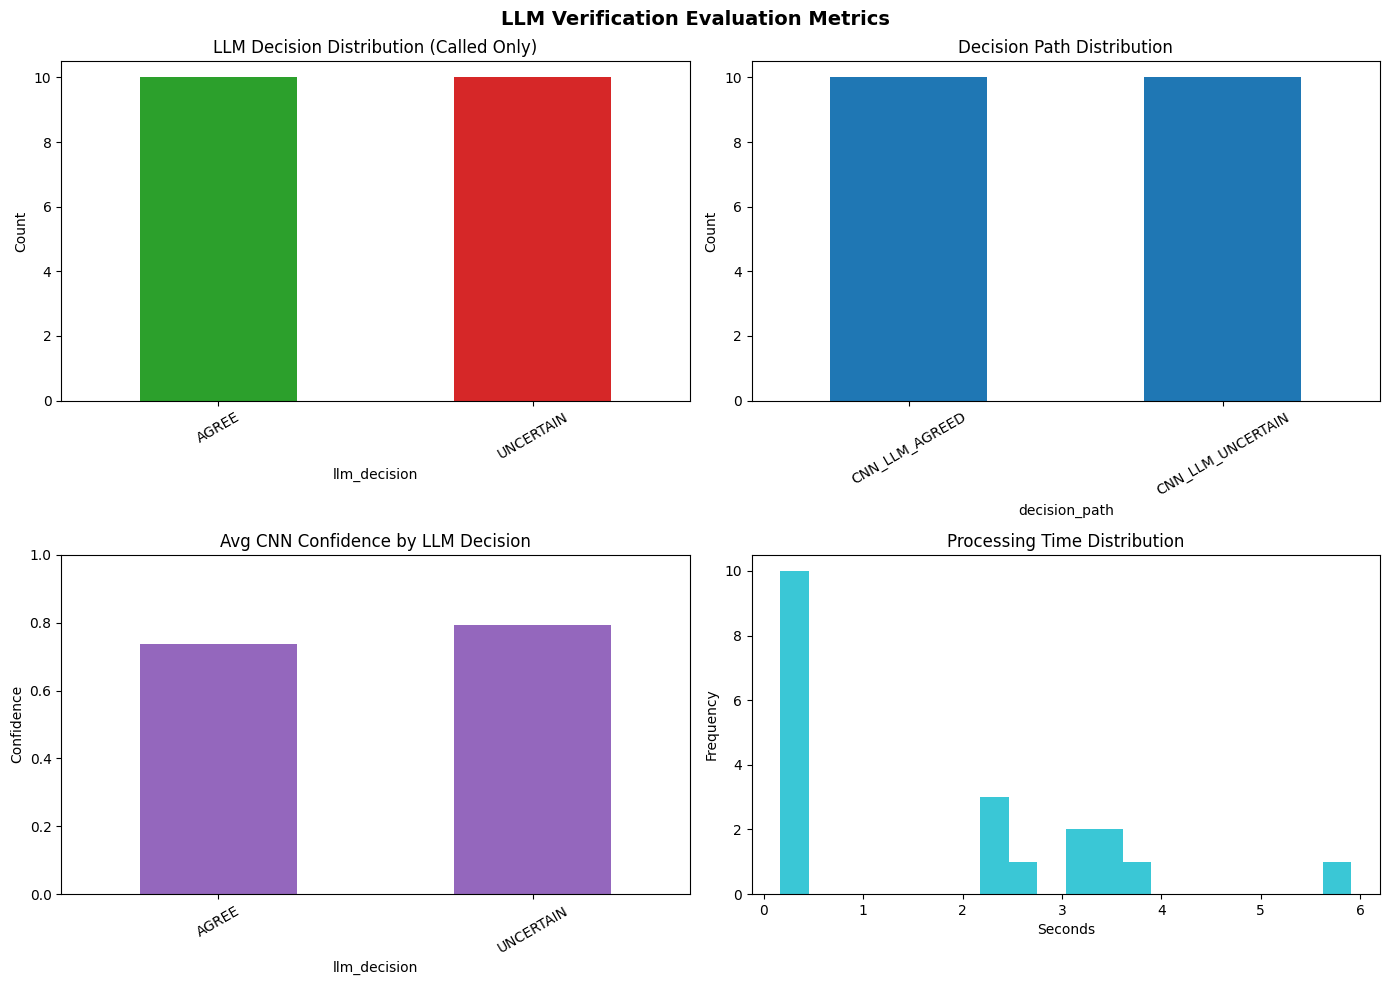

✅ Saved dashboard: llm_eval_metrics_dashboard.png


In [27]:
## 📏 Cell 10B: LLM Verification Evaluation Metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_llm_verification_metrics(results=None, csv_path='llm_verification_results.csv', make_plots=True):
    """
    Evaluate LLM verification behavior (without ground-truth labels).

    Metrics focus on LLM decision quality signals:
    - LLM invocation rate
    - AGREE / DISAGREE / UNCERTAIN decision rates
    - Decision path distribution
    - Risk-level and confusion-type distribution
    - Confidence, margin, entropy patterns by LLM decision
    - Latency metrics (mean/median/p95)
    - Manual-review trigger rate (DISAGREE path)
    """

    # ---------- Load data ----------
    if results is not None and isinstance(results, dict) and 'predictions' in results:
        df = pd.DataFrame(results['predictions'])
    else:
        csv_file = Path(csv_path)
        if not csv_file.exists():
            print("❌ No input found.")
            print("   Run Cell 10 first, or provide a valid CSV path.")
            return None
        df = pd.read_csv(csv_file)

    if df.empty:
        print("❌ No rows found for evaluation.")
        return None

    # Ensure required columns exist
    required_cols = ['confidence', 'entropy', 'margin', 'decision_path', 'llm_used', 'processing_time']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"❌ Missing required columns: {missing}")
        print("   Re-run Cell 10 to regenerate llm_verification_results.csv")
        return None

    # Normalize types
    df['llm_used'] = df['llm_used'].astype(bool)

    # If llm_decision is missing, infer from decision_path where possible
    if 'llm_decision' not in df.columns:
        df['llm_decision'] = np.where(
            df['decision_path'].str.contains('DISAGREED', na=False), 'DISAGREE',
            np.where(df['decision_path'].str.contains('AGREED', na=False), 'AGREE', 'N/A')
        )

    # ---------- Core counts ----------
    total = len(df)
    llm_called = int(df['llm_used'].sum())
    llm_not_called = total - llm_called

    llm_df = df[df['llm_used']].copy()
    decision_counts = llm_df['llm_decision'].value_counts(dropna=False) if len(llm_df) > 0 else pd.Series(dtype=int)

    agree_count = int(decision_counts.get('AGREE', 0))
    disagree_count = int(decision_counts.get('DISAGREE', 0))
    uncertain_count = int(decision_counts.get('UNCERTAIN', 0))

    # ---------- Derived metrics ----------
    metrics = {
        'total_samples': total,
        'llm_called': llm_called,
        'llm_not_called': llm_not_called,
        'llm_invocation_rate_%': (llm_called / total * 100) if total else 0.0,
        'llm_agree_rate_given_called_%': (agree_count / llm_called * 100) if llm_called else 0.0,
        'llm_disagree_rate_given_called_%': (disagree_count / llm_called * 100) if llm_called else 0.0,
        'llm_uncertain_rate_given_called_%': (uncertain_count / llm_called * 100) if llm_called else 0.0,
        'manual_review_trigger_rate_%': (disagree_count / total * 100) if total else 0.0,
        'avg_confidence_all': float(df['confidence'].mean()),
        'avg_margin_all': float(df['margin'].mean()),
        'avg_entropy_all': float(df['entropy'].mean()),
        'avg_latency_sec': float(df['processing_time'].mean()),
        'median_latency_sec': float(df['processing_time'].median()),
        'p95_latency_sec': float(df['processing_time'].quantile(0.95)),
    }

    # Confidence/uncertainty by LLM decision
    by_decision = pd.DataFrame()
    if llm_called > 0:
        by_decision = llm_df.groupby('llm_decision').agg(
            samples=('llm_decision', 'size'),
            avg_confidence=('confidence', 'mean'),
            avg_margin=('margin', 'mean'),
            avg_entropy=('entropy', 'mean'),
            avg_latency_sec=('processing_time', 'mean')
        ).sort_values('samples', ascending=False)

    # Risk-level and confusion-type distributions (if available)
    risk_dist = pd.Series(dtype=int)
    confusion_dist = pd.Series(dtype=int)

    if 'llm_risk_level' in llm_df.columns:
        risk_dist = llm_df['llm_risk_level'].fillna('N/A').value_counts()

    if 'llm_confusion_type' in llm_df.columns:
        confusion_dist = llm_df['llm_confusion_type'].fillna('N/A').value_counts()

    # Decision path distribution
    decision_path_dist = df['decision_path'].fillna('N/A').value_counts()

    # ---------- Print report ----------
    print("=" * 90)
    print("📏 LLM VERIFICATION EVALUATION REPORT")
    print("=" * 90)
    print(f"Total samples                     : {metrics['total_samples']}")
    print(f"LLM called                        : {metrics['llm_called']} ({metrics['llm_invocation_rate_%']:.2f}%)")
    print(f"LLM not called                    : {metrics['llm_not_called']}")
    print(f"LLM AGREE rate (given called)     : {metrics['llm_agree_rate_given_called_%']:.2f}%")
    print(f"LLM DISAGREE rate (given called)  : {metrics['llm_disagree_rate_given_called_%']:.2f}%")
    print(f"LLM UNCERTAIN rate (given called) : {metrics['llm_uncertain_rate_given_called_%']:.2f}%")
    print(f"Manual review trigger rate        : {metrics['manual_review_trigger_rate_%']:.2f}%")
    print("-" * 90)
    print(f"Avg confidence (all)              : {metrics['avg_confidence_all']:.4f}")
    print(f"Avg margin (all)                  : {metrics['avg_margin_all']:.4f}")
    print(f"Avg entropy (all)                 : {metrics['avg_entropy_all']:.4f}")
    print("-" * 90)
    print(f"Latency mean / median / p95 (s)   : {metrics['avg_latency_sec']:.3f} / {metrics['median_latency_sec']:.3f} / {metrics['p95_latency_sec']:.3f}")
    print("=" * 90)

    if len(by_decision) > 0:
        print("\n📊 Metrics by LLM Decision")
        print(by_decision.to_string(float_format=lambda x: f"{x:.4f}"))

    print("\n📈 Decision Path Distribution")
    print(decision_path_dist.to_string())

    if len(risk_dist) > 0:
        print("\n⚠️ Risk Level Distribution (LLM-called only)")
        print(risk_dist.to_string())

    if len(confusion_dist) > 0:
        print("\n🧠 Confusion Type Distribution (LLM-called only)")
        print(confusion_dist.to_string())

    # ---------- Exports ----------
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv('llm_eval_metrics_summary.csv', index=False)
    by_decision.to_csv('llm_eval_metrics_by_decision.csv')
    decision_path_dist.rename_axis('decision_path').reset_index(name='count').to_csv('llm_eval_decision_path_distribution.csv', index=False)

    if len(risk_dist) > 0:
        risk_dist.rename_axis('llm_risk_level').reset_index(name='count').to_csv('llm_eval_risk_distribution.csv', index=False)
    if len(confusion_dist) > 0:
        confusion_dist.rename_axis('llm_confusion_type').reset_index(name='count').to_csv('llm_eval_confusion_distribution.csv', index=False)

    print("\n✅ Exported:")
    print("   - llm_eval_metrics_summary.csv")
    print("   - llm_eval_metrics_by_decision.csv")
    print("   - llm_eval_decision_path_distribution.csv")
    if len(risk_dist) > 0:
        print("   - llm_eval_risk_distribution.csv")
    if len(confusion_dist) > 0:
        print("   - llm_eval_confusion_distribution.csv")

    # ---------- Optional plots ----------
    if make_plots:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('LLM Verification Evaluation Metrics', fontsize=14, fontweight='bold')

        # Plot 1: LLM decision distribution
        ax = axes[0, 0]
        if len(decision_counts) > 0:
            decision_counts.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'][:len(decision_counts)])
            ax.set_title('LLM Decision Distribution (Called Only)')
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=30)
        else:
            ax.text(0.5, 0.5, 'No LLM-called samples', ha='center', va='center')
            ax.set_title('LLM Decision Distribution')

        # Plot 2: Decision path distribution
        ax = axes[0, 1]
        decision_path_dist.plot(kind='bar', ax=ax, color='#1f77b4')
        ax.set_title('Decision Path Distribution')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=30)

        # Plot 3: Confidence by LLM decision
        ax = axes[1, 0]
        if llm_called > 0 and len(by_decision) > 0:
            by_decision['avg_confidence'].plot(kind='bar', ax=ax, color='#9467bd')
            ax.set_title('Avg CNN Confidence by LLM Decision')
            ax.set_ylabel('Confidence')
            ax.set_ylim(0, 1)
            ax.tick_params(axis='x', rotation=30)
        else:
            ax.text(0.5, 0.5, 'No LLM-called samples', ha='center', va='center')
            ax.set_title('Avg CNN Confidence by LLM Decision')

        # Plot 4: Latency histogram
        ax = axes[1, 1]
        ax.hist(df['processing_time'].dropna(), bins=20, color='#17becf', alpha=0.85)
        ax.set_title('Processing Time Distribution')
        ax.set_xlabel('Seconds')
        ax.set_ylabel('Frequency')

        plt.tight_layout()
        plt.savefig('llm_eval_metrics_dashboard.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Saved dashboard: llm_eval_metrics_dashboard.png")

    return {
        'metrics': metrics,
        'by_decision': by_decision,
        'decision_path_dist': decision_path_dist,
        'risk_dist': risk_dist,
        'confusion_dist': confusion_dist,
        'raw_df': df,
    }


# Run evaluation (after Cell 10)
if 'test_results' in globals() and test_results is not None:
    llm_eval = evaluate_llm_verification_metrics(results=test_results, make_plots=True)
else:
    print("ℹ️ `test_results` not found in memory.")
    print("   Trying CSV fallback: llm_verification_results.csv")
    llm_eval = evaluate_llm_verification_metrics(csv_path='llm_verification_results.csv', make_plots=True)


In [28]:
## 💾 Cell 11: Save Results to Google Drive

import shutil
from pathlib import Path

def save_results_to_drive(drive_folder='GTSRB_TwoStage/results'):
    """
    Save LLM verification results to Google Drive.
    
    Args:
        drive_folder: Folder path in Google Drive (relative to MyDrive)
    """
    if not IN_COLAB:
        print("⚠️ Not in Colab environment. Files are already saved locally.")
        return
    
    # Create Drive results folder
    drive_path = Path(f'/content/drive/MyDrive/{drive_folder}')
    drive_path.mkdir(parents=True, exist_ok=True)
    
    print("=" * 70)
    print("💾 SAVING RESULTS TO GOOGLE DRIVE")
    print("=" * 70)
    print(f"📁 Drive folder: {drive_path}")
    print()
    
    # Files to save
    files_to_save = [
        'llm_verification_results.csv',  # Cell 10 output
    ]
    
    saved_count = 0
    for filename in files_to_save:
        file_path = Path(filename)
        if file_path.exists():
            dest_path = drive_path / filename
            shutil.copy2(file_path, dest_path)
            print(f"✅ Saved: {filename}")
            saved_count += 1
        else:
            print(f"⚠️ Not found: {filename} (skipping)")
    
    print()
    print("=" * 70)
    print(f"✅ Saved {saved_count} file(s) to Google Drive!")
    print(f"📂 Location: {drive_path}")
    print("=" * 70)
    
    return drive_path

# Run save to Drive
if IN_COLAB:
    print("💾 Save results to Google Drive")
    print("   Usage: save_results_to_drive()")
    print()
    
    # Auto-save if results exist
    if Path('llm_verification_results.csv').exists():
        saved_path = save_results_to_drive()
    else:
        print("⚠️ No results found. Run Cell 10 first!")
else:
    print("💾 Files saved locally (not in Colab):")
    print("   - llm_verification_results.csv")

💾 Save results to Google Drive
   Usage: save_results_to_drive()

💾 SAVING RESULTS TO GOOGLE DRIVE
📁 Drive folder: /content/drive/MyDrive/GTSRB_TwoStage/results

✅ Saved: llm_verification_results.csv

✅ Saved 1 file(s) to Google Drive!
📂 Location: /content/drive/MyDrive/GTSRB_TwoStage/results


## 📝 Summary

### System Architecture
1. **IEEE Ensemble CNN** (ConvNeXt-Tiny + ResNet18 + EfficientNet-B0) with soft voting
2. **Confidence Gate** routes uncertain predictions to LLM
3. **LLM Semantic Verifier** (OpenRouter Llama 3.1 8B) analyzes confusion patterns using GTSRB visual hierarchy

### Key Design Principle
The LLM performs **semantic consistency verification**, not redundant confidence thresholding:
- **DOMINANT_PREDICTION**: Large margin (>50%) → AGREE (Top-2 is just noise)
- **FINE_GRAINED**: Same semantic group confusion (e.g., Speed 30 vs 50) → AGREE
- **STRUCTURAL_CONFLICT**: Cross-category confusion (e.g., Stop vs Speed limit) → DISAGREE
- **CLEAR_WINNER**: Moderate confidence with reasonable margin → AGREE

### LLM Configuration
- **Provider**: OpenRouter API
- **Model**: meta-llama/llama-3.1-8b-instruct
- **Temperature**: 0.2
- **Focus**: Semantic reasoning on traffic sign hierarchies

### Output Files
| File | Content |
|------|---------|
| `llm_verification_results.csv` | Detailed predictions with LLM decisions and reasoning |

### Testing Focus
This notebook demonstrates **LLM verification logic** - how the LLM reviews CNN predictions and makes semantic decisions:
- Shows CNN top-3 predictions with confidence
- Shows when LLM is called (confidence gate)
- Shows LLM decision (AGREE/DISAGREE) with reasoning
- Shows decision paths and processing times